🎯 Best Target Choice
battery_used_kWh → Regression

👉 This is correct because:

You want to predict how much battery is consumed per trip


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('ev_data.csv')

df.head()


,trip_id,distance_km,avg_speed_kmph,temperature_C,battery_used_kWh,battery_start_%,battery_end_%,driving_style
0,1,12.5,32,27,3.1,88,72,Normal
1,2,18.3,45,30,4.6,95,70,Aggressive
2,3,25.8,38,22,5.0,90,61,Normal
3,4,9.4,28,18,2.2,76,64,Calm
4,5,31.6,52,34,6.8,100,62,Aggressive


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   trip_id           120 non-null    int64  
 1   distance_km       120 non-null    float64
 2   avg_speed_kmph    120 non-null    int64  
 3   temperature_C     120 non-null    int64  
 4   battery_used_kWh  120 non-null    float64
 5   battery_start_%   120 non-null    int64  
 6   battery_end_%     120 non-null    int64  
 7   driving_style     120 non-null    str    
dtypes: float64(2), int64(5), str(1)
memory usage: 7.6 KB


In [4]:
df.describe()

,trip_id,distance_km,avg_speed_kmph,temperature_C,battery_used_kWh,battery_start_%,battery_end_%
count,120.000000,120.000000,120.000000,120.000000,120.00000,120.000000,120.000000
mean,60.500000,19.680000,40.741667,28.525000,4.45500,87.700000,69.958333
std,34.785054,6.244212,6.985574,3.906389,1.28173,6.678197,2.209209
min,1.000000,8.500000,27.000000,18.000000,2.00000,75.000000,61.000000
25%,30.750000,14.125000,34.750000,25.000000,3.27500,82.000000,70.000000
50%,60.500000,19.300000,41.000000,29.000000,4.60000,88.000000,70.000000
75%,90.250000,25.000000,46.000000,31.250000,5.60000,93.000000,71.000000
max,120.000000,31.600000,53.000000,36.000000,6.80000,100.000000,75.000000


In [5]:
df.isnull().sum()

trip_id             0
distance_km         0
avg_speed_kmph      0
temperature_C       0
battery_used_kWh    0
battery_start_%     0
battery_end_%       0
driving_style       0
dtype: int64

In [6]:
# Drop trip_id
df.drop("trip_id", axis=1, inplace=True)

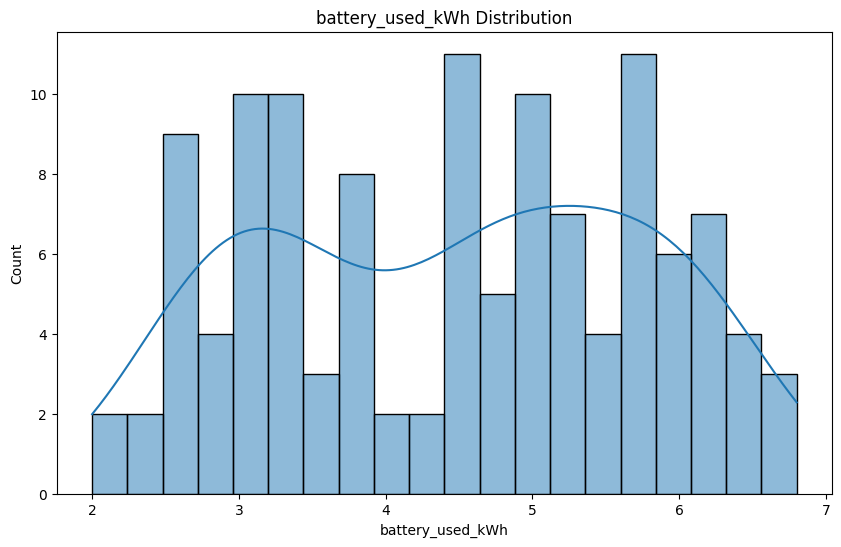

In [9]:
# Visualize the distribution of battery consumption
plt.figure(figsize=(10, 6))
sns.histplot(df['battery_used_kWh'], bins=20, kde=True)
plt.title('battery_used_kWh Distribution')
plt.show()

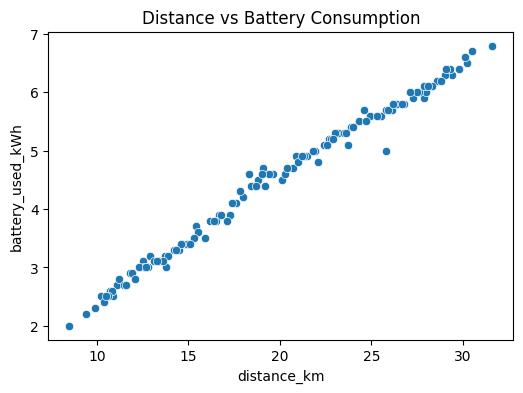

In [10]:
plt.figure(figsize=(6,4))
sns.scatterplot(x="distance_km", y="battery_used_kWh", data=df)
plt.title("Distance vs Battery Consumption")
plt.show()


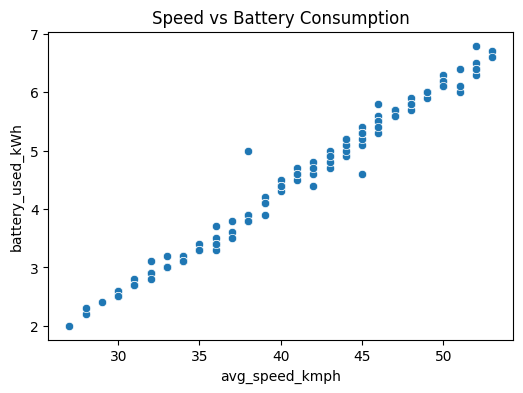

In [11]:
plt.figure(figsize=(6,4))
sns.scatterplot(x="avg_speed_kmph", y="battery_used_kWh", data=df)
plt.title("Speed vs Battery Consumption")
plt.show()


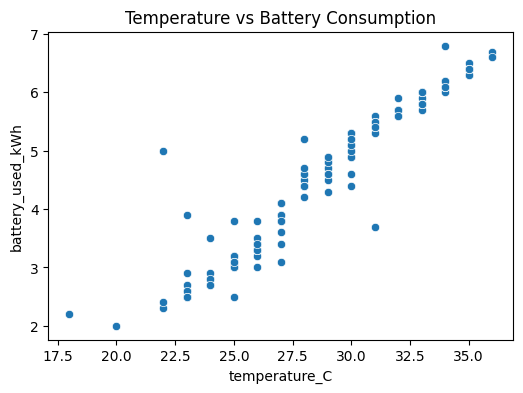

In [12]:
plt.figure(figsize=(6,4))
sns.scatterplot(x="temperature_C", y="battery_used_kWh", data=df)
plt.title("Temperature vs Battery Consumption")
plt.show()

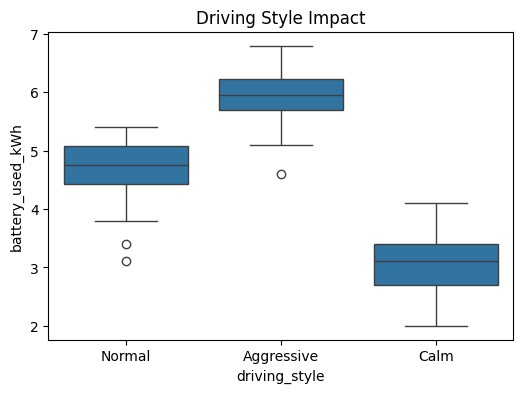

In [13]:
plt.figure(figsize=(6,4))
sns.boxplot(x="driving_style", y="battery_used_kWh", data=df)
plt.title("Driving Style Impact")
plt.show()

In [15]:
df["efficiency_kWh_per_km"] = df["battery_used_kWh"] / df["distance_km"]

df['efficiency_kWh_per_km']

0      0.248000
1      0.251366
2      0.193798
3      0.234043
4      0.215190
         ...   
115    0.238095
116    0.231132
117    0.219931
118    0.231707
119    0.227074
Name: efficiency_kWh_per_km, Length: 120, dtype: float64

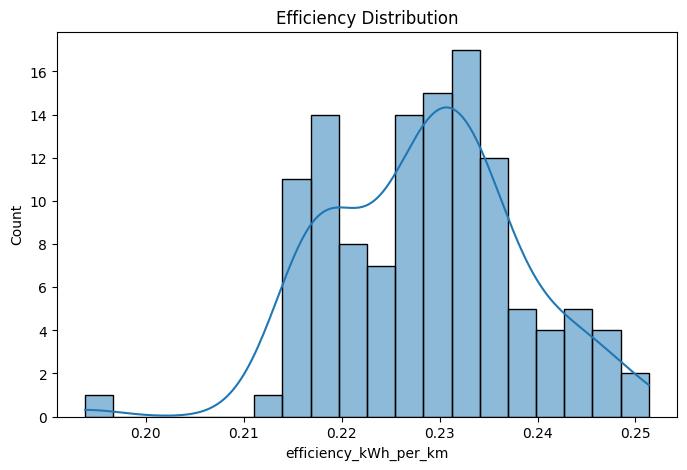

In [16]:
plt.figure(figsize=(8,5))
sns.histplot(df["efficiency_kWh_per_km"], bins=20, kde=True)
plt.title("Efficiency Distribution")
plt.show()

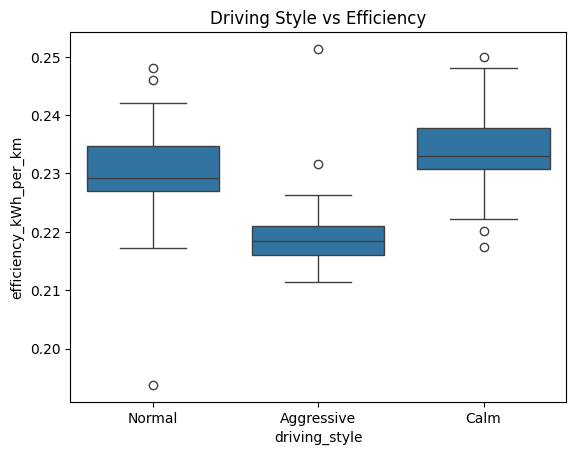

In [17]:
sns.boxplot(x="driving_style", y="efficiency_kWh_per_km", data=df)
plt.title("Driving Style vs Efficiency")
plt.show()

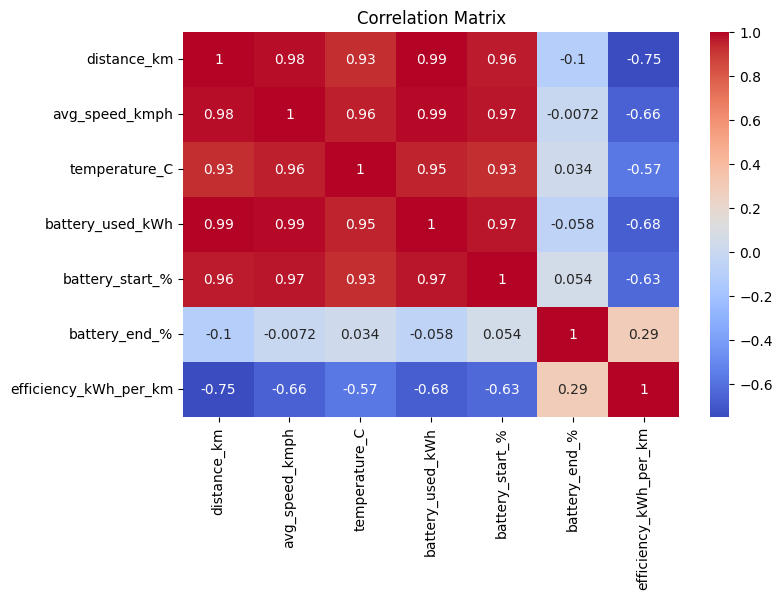

In [18]:
plt.figure(figsize=(8,5))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

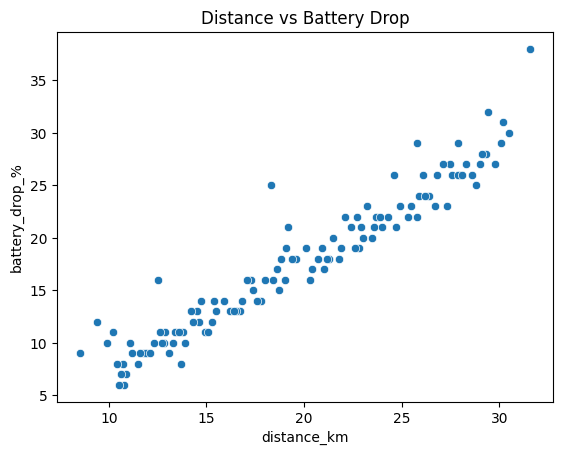

In [20]:
df["battery_drop_%"] = df["battery_start_%"] - df["battery_end_%"]

df["battery_drop_%"]

sns.scatterplot(x="distance_km", y="battery_drop_%", data=df)
plt.title("Distance vs Battery Drop")
plt.show()

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [22]:
df["driving_style"] = df["driving_style"].map({
    "eco": 0,
    "normal": 1,
    "aggressive": 2
})

In [ ]:
#  target variables
x = df.drop(["battery_used_kWh"], axis=1)
y= df["battery_used_kWh"]

X_train, X_test, Y_train, Y_test = train_test_split(x,y, test_size=0.2, random_state=42)


In [24]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, Y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [25]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(Y_test, y_pred)
rmse = np.sqrt(mean_squared_error(Y_test, y_pred))


print(f"Mean Absolute Error: {mae:.2f} kWh")
print(f"Root Mean Squared Error: {rmse:.2f} kWh")


Mean Absolute Error: 0.09 kWh
Root Mean Squared Error: 0.12 kWh


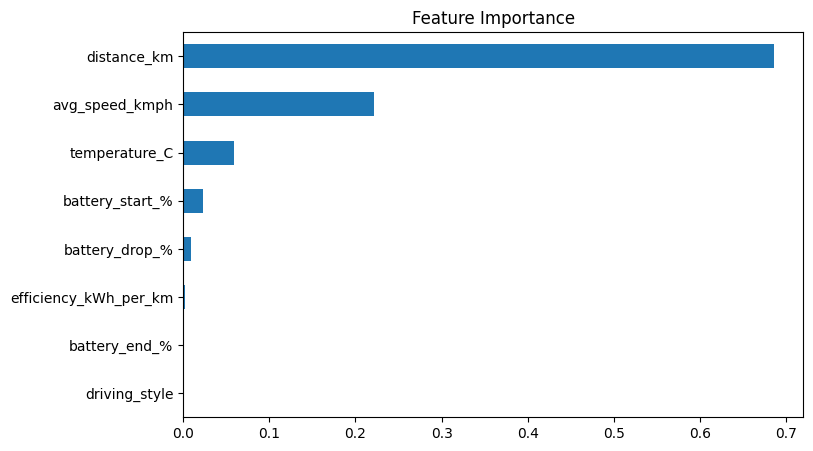

In [27]:
importances = pd.Series(model.feature_importances_, index=x.columns)
importances.sort_values().plot(kind="barh", figsize=(8,5))
plt.title("Feature Importance")
plt.show()

In [28]:
import pickle

with open("ev_battery_model.pkl", "wb") as f:
    pickle.dump(model, f)

In [29]:
sample = pd.DataFrame([{
    "distance_km": 50,
    "avg_speed_kmph": 60,
    "temperature_C": 25,
    "battery_start_%": 90,
    "battery_end_%": 70,
    "driving_style": 1,
    "efficiency_kWh_per_km": 0.15,
    "battery_drop_%": 20
}])

prediction = model.predict(sample)
print("Predicted Battery Usage:", prediction[0])

Predicted Battery Usage: 5.963000000000003
